In [2]:
import os
from matplotlib import figure
print("Jupyter is looking here:", os.getcwd())

Jupyter is looking here: /home/owais/PycharmProjects/AUTOWORTH_BACKEND


Visualizing Data Befor Starting Using Seabron

<Axes: xlabel='selling_price', ylabel='Count'>

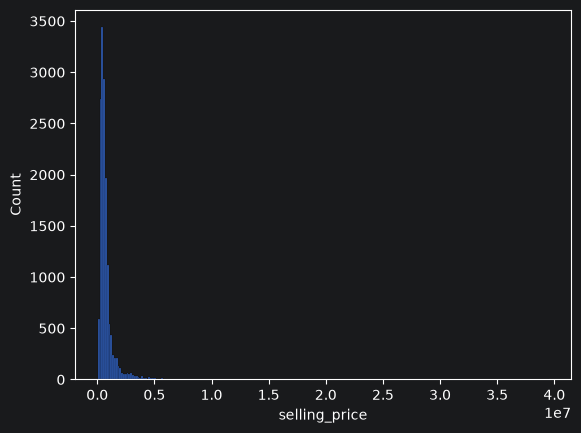

In [3]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("car.csv")
sns.histplot(df["selling_price"])

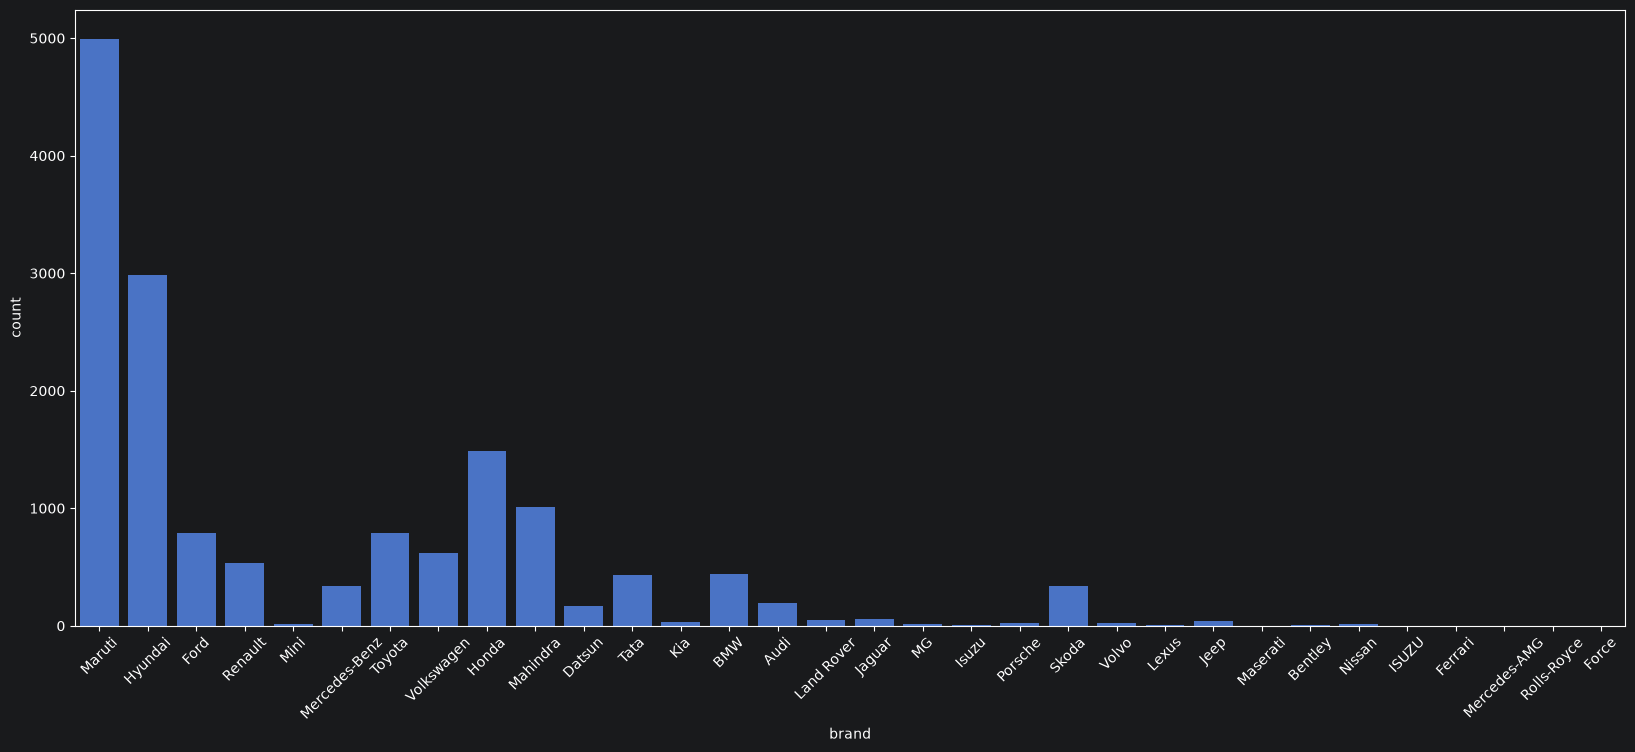

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,8))
sns.countplot(data=df, x="brand")
plt.xticks(rotation=45)
plt.show()

0         120000
1         550000
2         215000
3         226000
4         570000
          ...   
15406     250000
15407     925000
15408     425000
15409    1225000
15410    1200000
Name: selling_price, Length: 15411, dtype: int64


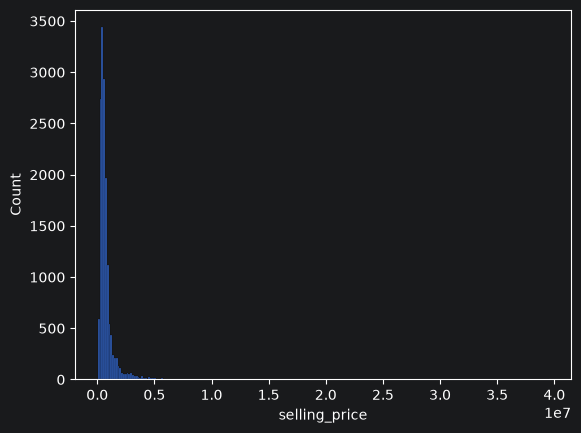

In [5]:
df["selling_price_lakh"] = df["selling_price"] / 100000
sns.histplot(df["selling_price"])
print(df["selling_price"])

Checking for skewness so we can decide which Function Transformer to apply

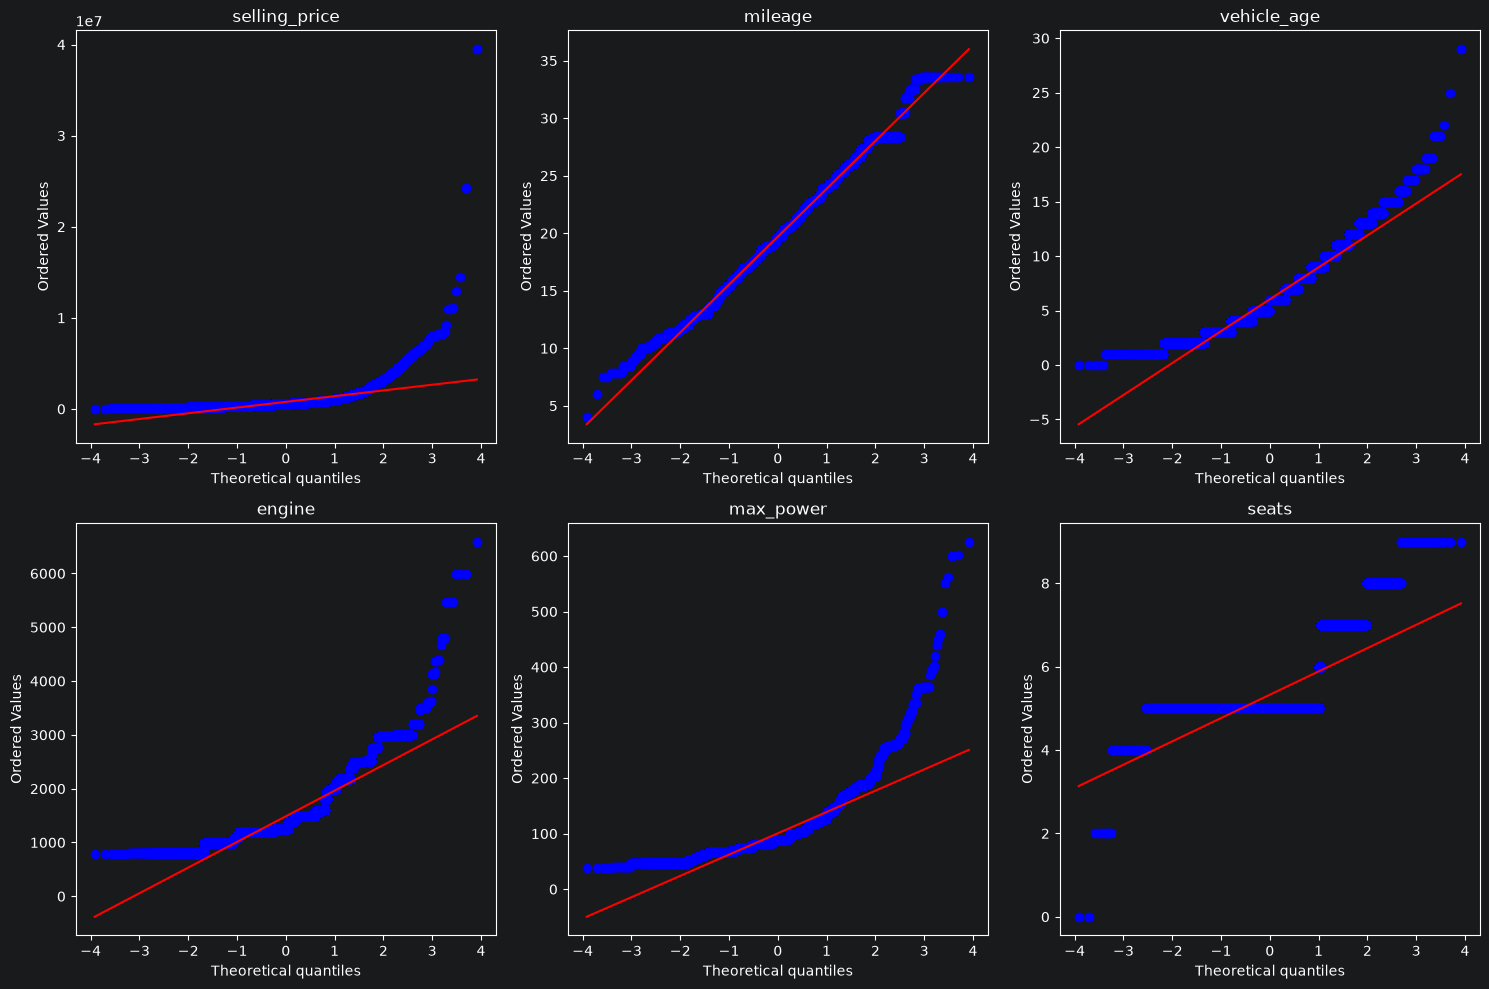

In [6]:
from scipy import stats
import matplotlib.pyplot as plt

columns = [
    "selling_price",
    "mileage",
    "vehicle_age",
    "engine",
    "max_power",
    "seats"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(columns, 1):
    plt.subplot(2, 3, i)   # 2 rows, 3 columns
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(col)

plt.tight_layout()
plt.show()

In [7]:
print(df[[
    "selling_price",
    "mileage",
    "vehicle_age",
    "engine",
    "max_power",
    "seats"
]].skew())

selling_price    10.047048
mileage           0.104961
vehicle_age       0.833712
engine            1.666467
max_power         2.485129
seats             2.039983
dtype: float64


AFTER ANAYZING DATA NW DOING DATA CLEANING PROCESS

In [9]:
df.shape

(15411, 15)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          15411 non-null  int64  
 1   car_name            15411 non-null  str    
 2   brand               15411 non-null  str    
 3   model               15411 non-null  str    
 4   vehicle_age         15411 non-null  int64  
 5   km_driven           15411 non-null  int64  
 6   seller_type         15411 non-null  str    
 7   fuel_type           15411 non-null  str    
 8   transmission_type   15411 non-null  str    
 9   mileage             15411 non-null  float64
 10  engine              15411 non-null  int64  
 11  max_power           15411 non-null  float64
 12  seats               15411 non-null  int64  
 13  selling_price       15411 non-null  int64  
 14  selling_price_lakh  15411 non-null  float64
dtypes: float64(3), int64(6), str(6)
memory usage: 1.8 MB


In [11]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,selling_price_lakh
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000,1.20
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000,5.50
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000,2.15
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000,2.26
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000,5.70


In [13]:
df.isnull().sum()

Unnamed: 0            0
car_name              0
brand                 0
model                 0
vehicle_age           0
km_driven             0
seller_type           0
fuel_type             0
transmission_type     0
mileage               0
engine                0
max_power             0
seats                 0
selling_price         0
selling_price_lakh    0
dtype: int64

Identify Unique Values in Each Colummn

In [16]:
for col in ['brand', 'fuel_type', 'transmission_type', 'seller_type']:
    print(col, df[col].unique())

brand <StringArray>
[       'Maruti',       'Hyundai',          'Ford',       'Renault',
          'Mini', 'Mercedes-Benz',        'Toyota',    'Volkswagen',
         'Honda',      'Mahindra',        'Datsun',          'Tata',
           'Kia',           'BMW',          'Audi',    'Land Rover',
        'Jaguar',            'MG',         'Isuzu',       'Porsche',
         'Skoda',         'Volvo',         'Lexus',          'Jeep',
      'Maserati',       'Bentley',        'Nissan',         'ISUZU',
       'Ferrari',  'Mercedes-AMG',   'Rolls-Royce',         'Force']
Length: 32, dtype: str
fuel_type <StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str
transmission_type <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
seller_type <StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str


Chekcing For Duplicates

In [15]:
for col in df.columns:
    duplicates = df[col].duplicated().sum()
    print(f"{col}: {duplicates}")

Unnamed: 0: 0
car_name: 15290
brand: 15379
model: 15291
vehicle_age: 15387
km_driven: 11723
seller_type: 15408
fuel_type: 15406
transmission_type: 15409
mileage: 15000
engine: 15301
max_power: 15069
seats: 15403
selling_price: 14325
selling_price_lakh: 14325


In [20]:
df['model'].nunique()

df['vehicle_age'].nunique()

24

In [21]:
df.groupby(['brand', 'model']).ngroups

121

In [22]:
df.groupby(['brand', 'model', 'vehicle_age']).ngroups

811

In [23]:
df.groupby(['brand', 'model', 'vehicle_age', 'km_driven']).ngroups

11871

In [24]:
df.groupby(['brand', 'model', 'vehicle_age', 'km_driven', 'selling_price']).ngroups

15085

In [25]:
df.duplicated().sum()

np.int64(0)

                                    TRAINING MODELS AFTER THOROUGH DATA ANALYSIS